# Topology-Specific Policy versus Flexible Topology-Aware RLC-FT

This notebook uses the current fixed-X checkpoint selection (`Step 300`, no extra action scaling). The training-network comparison uses the exact network used by the topology-specific controller. The flexible-shift comparison uses sampled topology changes with a line-admittance multiplier of 1.2, matching the stress setting used in the current topology/admittance-shift test.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import Config

fixed_tag = 'fixed_x_calibrated_la7p5_seed4_20260626'
result_dir = (
    Path(Config.data_path)
    / 'images'
    / '56bus'
    / 'fixed_x_topology_shift'
    / fixed_tag
    / 'selected_step300_admittance1p2_actionscale10'
)

raw_path = result_dir / 'fixed_x_comparison_raw.csv'
summary_path = result_dir / 'fixed_x_comparison_summary.csv'
ratio_path = result_dir / 'fixed_x_comparison_paired_ratio.csv'

raw = pd.read_csv(raw_path)
summary = pd.read_csv(summary_path)
ratio_summary = pd.read_csv(ratio_path)

method_order = ['RLC-FT', 'Topology-specific RLC-FT', 'Linear']
method_labels = ['RLC-FT', 'Topology-specific\nRLC-FT', 'Linear']
regime_order = ['training_network', 'flexible_shifts']
regime_labels = {
    'training_network': 'Training network',
    'flexible_shifts': 'Flexible topology/admittance shifts',
}
colors = {
    'RLC-FT': '#2C7FB8',
    'Topology-specific RLC-FT': '#F28E2B',
    'Linear': '#8A8A8A',
}

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120,
})

print('result_dir:', result_dir)
summary


result_dir: D:\Code\Python\Flexible_Voltage_Control\images\56bus\fixed_x_topology_shift\fixed_x_calibrated_la7p5_seed4_20260626\selected_step300_admittance1p2_actionscale10


,regime,method,recovery_median,recovery_q25,recovery_q75,objective_median,objective_q25,objective_q75,recovered_rate,n
0,flexible_shifts,Linear,47.5,25.0,67.5,679.119846,377.085768,982.767866,1.00,100
1,flexible_shifts,RLC-FT,6.0,3.0,10.0,118.993982,83.413934,185.412619,1.00,100
2,flexible_shifts,Topology-specific RLC-FT,7.0,4.0,11.0,121.502377,77.811585,182.516785,0.98,100
3,training_network,Linear,45.0,18.0,58.0,601.920818,263.031128,729.045874,1.00,100
4,training_network,RLC-FT,5.0,3.0,9.0,106.486668,68.389234,152.683426,1.00,100
5,training_network,Topology-specific RLC-FT,5.0,3.0,7.0,111.486928,69.150189,150.426478,1.00,100


In [2]:
def add_median_labels(ax, x, values, mode):
    yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    offset = 0.018 * yrange
    for xi, val in zip(x, values):
        if mode == 'ratio':
            text = f'{val:.2f}'
        elif mode == 'steps':
            text = f'{val:.1f}' if abs(val - round(val)) > 1e-6 else f'{val:.0f}'
        else:
            text = f'{val:.0f}'
        ax.text(
            xi,
            val + offset,
            text,
            ha='center',
            va='bottom',
            fontsize=9,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.75, 'pad': 0.8},
        )

def finish_panel(ax):
    ax.grid(axis='y', alpha=0.22, linewidth=0.8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', length=0)

def add_row_titles(fig):
    fig.text(0.515, 0.905, regime_labels['training_network'], ha='center', va='center', fontsize=13, fontweight='semibold')
    fig.text(0.515, 0.462, regime_labels['flexible_shifts'], ha='center', va='center', fontsize=13, fontweight='semibold')


saved: D:\Code\Python\Flexible_Voltage_Control\images\56bus\fixed_x_topology_shift\fixed_x_calibrated_la7p5_seed4_20260626\selected_step300_admittance1p2_actionscale10\fixed_x_step300_train_network_flexible1p2_median_iqr.png
saved: D:\Code\Python\Flexible_Voltage_Control\images\56bus\fixed_x_topology_shift\fixed_x_calibrated_la7p5_seed4_20260626\selected_step300_admittance1p2_actionscale10\fixed_x_step300_train_network_flexible1p2_median_iqr.pdf


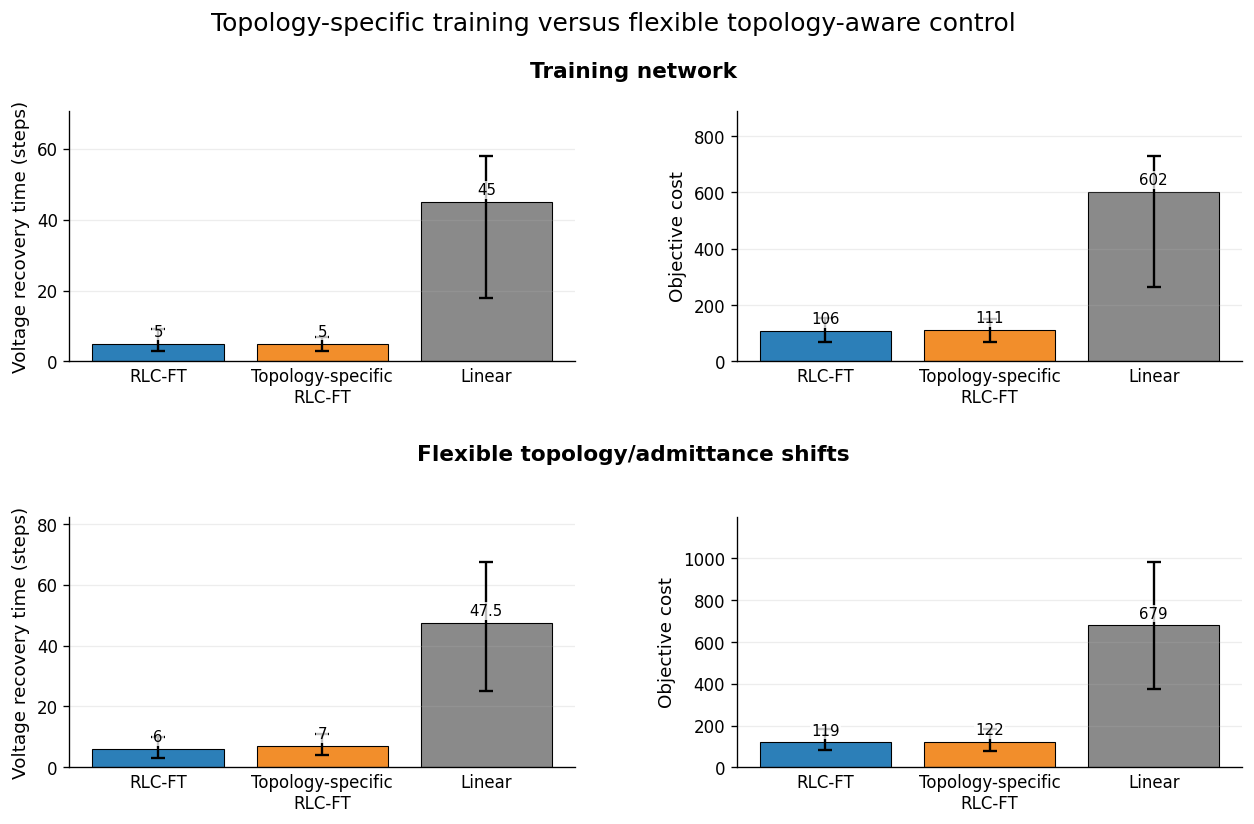

In [3]:
# Absolute median [IQR]. The label above each bar gives the median; the error bar shows the IQR.
metric_specs = [
    ('recovery', 'Voltage recovery time (steps)', 'steps'),
    ('objective', 'Objective cost', 'objective'),
]

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.2), constrained_layout=False)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.10, top=0.86, hspace=0.62, wspace=0.32)
add_row_titles(fig)

for row_idx, regime in enumerate(regime_order):
    sub = summary[summary['regime'] == regime].set_index('method').loc[method_order]
    for col_idx, (metric, ylabel, mode) in enumerate(metric_specs):
        ax = axes[row_idx, col_idx]
        med = sub[f'{metric}_median']
        q25 = sub[f'{metric}_q25']
        q75 = sub[f'{metric}_q75']
        x = np.arange(len(method_order))
        yerr = np.vstack([med.to_numpy() - q25.to_numpy(), q75.to_numpy() - med.to_numpy()])
        ax.bar(
            x,
            med.to_numpy(),
            yerr=yerr,
            capsize=4,
            color=[colors[m] for m in method_order],
            edgecolor='black',
            linewidth=0.65,
            error_kw={'elinewidth': 1.4, 'capthick': 1.4},
        )
        ax.set_xticks(x)
        ax.set_xticklabels(method_labels)
        ax.set_ylabel(ylabel)
        ymax = max(q75.to_numpy()) * 1.22
        ax.set_ylim(0, ymax)
        add_median_labels(ax, x, med.to_numpy(), mode)
        finish_panel(ax)

fig.suptitle('Topology-specific training versus flexible topology-aware control', fontsize=15, y=0.975)
raw_fig_png = result_dir / 'fixed_x_step300_train_network_flexible1p2_median_iqr.png'
raw_fig_pdf = result_dir / 'fixed_x_step300_train_network_flexible1p2_median_iqr.pdf'
fig.savefig(raw_fig_png, dpi=300, bbox_inches='tight')
fig.savefig(raw_fig_pdf, bbox_inches='tight')
print('saved:', raw_fig_png)
print('saved:', raw_fig_pdf)
plt.show()


saved: D:\Code\Python\Flexible_Voltage_Control\images\56bus\fixed_x_topology_shift\fixed_x_calibrated_la7p5_seed4_20260626\selected_step300_admittance1p2_actionscale10\fixed_x_step300_train_network_flexible1p2_paired_ratio.png
saved: D:\Code\Python\Flexible_Voltage_Control\images\56bus\fixed_x_topology_shift\fixed_x_calibrated_la7p5_seed4_20260626\selected_step300_admittance1p2_actionscale10\fixed_x_step300_train_network_flexible1p2_paired_ratio.pdf


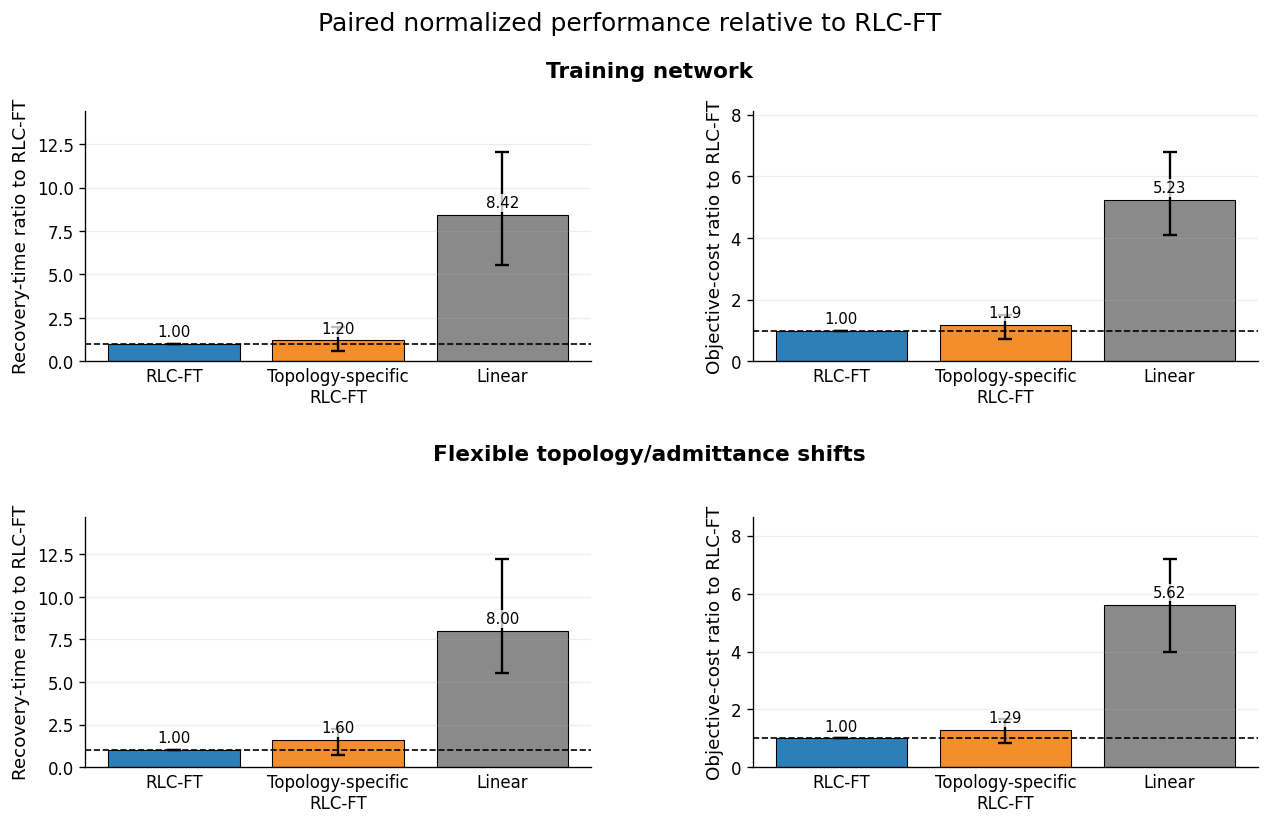

In [4]:
# Paired normalized view. RLC-FT is explicitly shown as the 1.0 reference.
ratio_metric_specs = [
    ('recovery_time', 'Recovery-time ratio to RLC-FT'),
    ('objective_cost', 'Objective-cost ratio to RLC-FT'),
]

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.2), constrained_layout=False)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.10, top=0.86, hspace=0.62, wspace=0.32)
add_row_titles(fig)

for row_idx, regime in enumerate(regime_order):
    for col_idx, (metric, ylabel) in enumerate(ratio_metric_specs):
        ax = axes[row_idx, col_idx]
        sub = (
            ratio_summary[(ratio_summary['regime'] == regime) & (ratio_summary['metric'] == metric)]
            .set_index('method')
            .loc[method_order]
        )
        med = sub['ratio_median']
        q25 = sub['ratio_q25']
        q75 = sub['ratio_q75']
        x = np.arange(len(method_order))
        yerr = np.vstack([med.to_numpy() - q25.to_numpy(), q75.to_numpy() - med.to_numpy()])
        ax.bar(
            x,
            med.to_numpy(),
            yerr=yerr,
            capsize=4,
            color=[colors[m] for m in method_order],
            edgecolor='black',
            linewidth=0.65,
            error_kw={'elinewidth': 1.4, 'capthick': 1.4},
        )
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0)
        ax.set_xticks(x)
        ax.set_xticklabels(method_labels)
        ax.set_ylabel(ylabel)
        ymax = max(q75.to_numpy()) * 1.20
        ax.set_ylim(0, ymax)
        add_median_labels(ax, x, med.to_numpy(), 'ratio')
        finish_panel(ax)

fig.suptitle('Paired normalized performance relative to RLC-FT', fontsize=15, y=0.975)
ratio_fig_png = result_dir / 'fixed_x_step300_train_network_flexible1p2_paired_ratio.png'
ratio_fig_pdf = result_dir / 'fixed_x_step300_train_network_flexible1p2_paired_ratio.pdf'
fig.savefig(ratio_fig_png, dpi=300, bbox_inches='tight')
fig.savefig(ratio_fig_pdf, bbox_inches='tight')
print('saved:', ratio_fig_png)
print('saved:', ratio_fig_pdf)
plt.show()


In [5]:
print('Absolute median [IQR]')
for regime in regime_order:
    print()
    print(regime_labels[regime])
    sub = summary[summary['regime'] == regime].set_index('method').loc[method_order]
    for method in method_order:
        r = sub.loc[method]
        print(
            f"{method:28s} | recovery {r.recovery_median:.1f} "
            f"[{r.recovery_q25:.1f}, {r.recovery_q75:.1f}] | "
            f"objective {r.objective_median:.1f} [{r.objective_q25:.1f}, {r.objective_q75:.1f}] | "
            f"recovered {100*r.recovered_rate:.0f}%"
        )

print('\nPaired ratios relative to RLC-FT')
print(ratio_summary.to_string(index=False))


Absolute median [IQR]

Training network
RLC-FT                       | recovery 5.0 [3.0, 9.0] | objective 106.5 [68.4, 152.7] | recovered 100%
Topology-specific RLC-FT     | recovery 5.0 [3.0, 7.0] | objective 111.5 [69.2, 150.4] | recovered 100%
Linear                       | recovery 45.0 [18.0, 58.0] | objective 601.9 [263.0, 729.0] | recovered 100%

Flexible topology/admittance shifts
RLC-FT                       | recovery 6.0 [3.0, 10.0] | objective 119.0 [83.4, 185.4] | recovered 100%
Topology-specific RLC-FT     | recovery 7.0 [4.0, 11.0] | objective 121.5 [77.8, 182.5] | recovered 98%
Linear                       | recovery 47.5 [25.0, 67.5] | objective 679.1 [377.1, 982.8] | recovered 100%

Paired ratios relative to RLC-FT
          regime         metric                   method  ratio_median  ratio_q25  ratio_q75   n
training_network  recovery_time                   RLC-FT      1.000000   1.000000   1.000000 100
training_network  recovery_time Topology-specific RLC-FT      